In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import glob

print("Library berhasil di-import!")

Library berhasil di-import!


In [ ]:
# 1. Mount Google Drive untuk menghubungkan Colab dengan penyimpanan Anda
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# 2. Menyalin FOLDER dataset yang sudah diekstrak dari Google Drive ke direktori lokal Colab
# Tambahkan tujuan salinannya yaitu '/content/dataset' di akhir perintah
!cp -r '/content/drive/MyDrive/For Public Use/Dataset Capstone 4 Ishak' '/content/dataset'

# 3. Memverifikasi apakah data sudah berhasil disalin ke dalam folder lokal Colab
import os
if os.path.exists('/content/dataset'):
    print("Folder dataset berhasil disalin ke environment lokal Colab!")
    print("Isi direktori dataset:")
    print(os.listdir('/content/dataset'))
else:
    print("Gagal menyalin. Pastikan path sumber dari Google Drive sudah benar.")

Folder dataset berhasil disalin ke environment lokal Colab!
Isi direktori dataset:
['train', 'data.yaml', 'valid', 'model_best_10_epoch.pt', 'model_best_100_epoch.pt', 'model_best_5_epoch.pt', 'README.roboflow.txt', 'README.dataset.txt', 'test']


In [ ]:
import yaml
import os

yaml_path = '/content/dataset/data.yaml'

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Jumlah Kelas:", data_config['nc'])
print("Nama Kelas:", data_config['names'])

Jumlah Kelas: 5
Nama Kelas: ['helmet', 'no-helmet', 'no-vest', 'person', 'vest']


In [ ]:
import warnings
# Menyembunyikan warning bawaan albumentations karena kita sengaja tidak mengubah geometri gambar
warnings.filterwarnings("ignore", category=UserWarning, module="albumentations")

# Mendefinisikan pipeline augmentasi HANYA warna/piksel (TANPA rotasi atau flip)
train_transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.GaussNoise(p=0.15), # var_limit dihapus menyesuaikan versi Albumentations terbaru
    A.RandomGamma(gamma_limit=(80, 120), p=0.3)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print("Pipeline augmentasi berhasil diperbarui. Rotasi dan flip dinonaktifkan.")

Pipeline augmentasi berhasil diperbarui. Rotasi dan flip dinonaktifkan.


/tmp/ipykernel_2080/2287536858.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(50.0, 100.0), p=1.0)


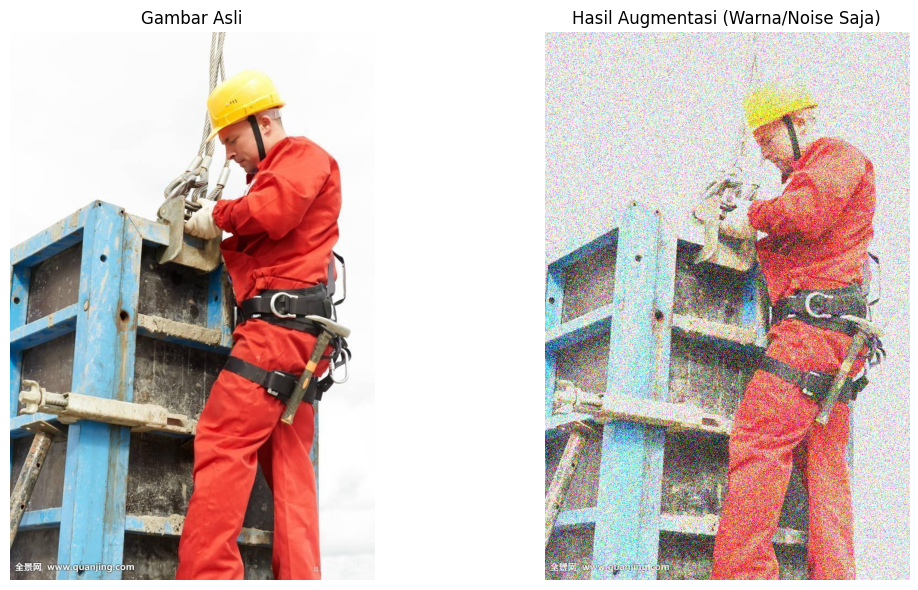

In [ ]:
# Mencari satu gambar acak dari folder train
image_files = glob.glob('/content/dataset/train/images/*.jpg')

if len(image_files) > 0:
    contoh_gambar_path = image_files[0] # Ambil gambar pertama

    # Membaca gambar
    image = cv2.imread(contoh_gambar_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Konversi BGR ke RGB untuk Matplotlib

    # Karena kita hanya menguji gambar (tanpa bounding box dulu), kita pakai transform sedikit berbeda
    # khusus untuk visualisasi gambar saja
    test_transform = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=1.0), # p=1.0 agar efeknya pasti terlihat
        A.GaussNoise(var_limit=(50.0, 100.0), p=1.0)
    ])

    augmented = test_transform(image=image)
    augmented_image = augmented['image']

    # Menampilkan hasil
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(image)
    ax[0].set_title("Gambar Asli")
    ax[0].axis('off')

    ax[1].imshow(augmented_image)
    ax[1].set_title("Hasil Augmentasi (Warna/Noise Saja)")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Folder gambar tidak ditemukan atau kosong. Coba cek kembali path direktori.")

In [ ]:
import yaml

yaml_path = '/content/dataset/data.yaml'

# Membaca isi data.yaml
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Memperbaiki path agar mengarah ke folder yang benar sesuai temuan radar kita
data_config['train'] = '/content/dataset/train/images'
data_config['val'] = '/content/dataset/valid/images' # Asumsi validasi ada di sini, sesuaikan jika bersembunyi juga
# Jika validasi ada di construction/valid/images, gunakan path tersebut.
# Kita gunakan path absolut untuk amannya.

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("Isi data.yaml yang baru:")
print(yaml.dump(data_config))

Isi data.yaml yang baru:
names:
- helmet
- no-helmet
- no-vest
- person
- vest
nc: 5
roboflow:
  license: CC BY 4.0
  project: construction-safety-gsnvb-jl6el
  url: https://universe.roboflow.com/personal-project-kej16/construction-safety-gsnvb-jl6el/dataset/1
  version: 1
  workspace: personal-project-kej16
test: ../test/images
train: /content/dataset/train/images
val: /content/dataset/valid/images



In [ ]:
# Install library YOLOv8
!pip install ultralytics -q

from ultralytics import YOLO
import os

print("YOLOv8 siap digunakan!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 7.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLOv8 siap digunakan!


**Training Data dimulai dari sini~** ✍

In [ ]:
# Memuat arsitektur model pre-trained YOLOv8
model = YOLO('yolov8n.pt')

# Memulai Fine-Tuning
# epochs=50 (bisa dinaikkan nanti jika kurang akurat), imgsz=640 adalah ukuran standar
print("Memulai proses fine-tuning...")
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=125,
    patience=30, # AKAN BERHENTI jika dalam 30 epoch berturut-turut tidak ada perbaikan
    imgsz=640,
    project='capstone',
    name='construction_safety',
    plots=True # Untuk menghasilkan grafik evaluasi metrik (F1-score, dll)
)

print("Fine-tuning selesai!")

Memulai proses fine-tuning...
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=125, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=construction_safety

In [ ]:
import shutil
import os

# YOLO secara otomatis menyimpan bobot terbaik di folder project/name/weights/best.pt
sumber_model = '/content/runs/detect/capstone/construction_safety/weights/best.pt'

# Target direktori di Google Drive sesuai permintaan Anda
target_dir = '/content/drive/MyDrive/For Public Use/Dataset Capstone 4 Ishak'
tujuan_model = os.path.join(target_dir, 'model_best_125_epoch.pt')

if os.path.exists(sumber_model):
    # Menyalin file ke Google Drive
    shutil.copy(sumber_model, tujuan_model)
    print(f"Mantap! Model berhasil diamankan dan disimpan ke: {tujuan_model}")
else:
    print("Wah, model tidak ditemukan. Pastikan proses training di Sel 3 sudah selesai 100% ya.")

Mantap! Model berhasil diamankan dan disimpan ke: /content/drive/MyDrive/For Public Use/Dataset Capstone 4 Ishak/model_best_125_epoch.pt


In [ ]:
# Membuat file utils.py secara pasti menggunakan Python I/O
kode_utils = """
def analyze_safety(detections_list):
    counts = {
        'person': detections_list.count('person'),
        'helmet': detections_list.count('helmet'),
        'vest': detections_list.count('vest'),
        'no-helmet': detections_list.count('no-helmet'),
        'no-vest': detections_list.count('no-vest')
    }

    persons = counts['person']
    helmets = counts['helmet']
    vests = counts['vest']

    pekerja_tanpa_helm = max(0, persons - helmets)
    pekerja_tanpa_vest = max(0, persons - vests)
    pekerja_tidak_lengkap = max(pekerja_tanpa_helm, pekerja_tanpa_vest)

    if persons == 0:
        pesan = "Tidak ada pekerja yang terdeteksi di area."
    elif pekerja_tidak_lengkap == 0:
        pesan = f"Aman! Seluruh {persons} pekerja menggunakan alat keselamatan lengkap."
    else:
        pesan = f"PERINGATAN: Terdeteksi {persons} pekerja. Terdapat {pekerja_tidak_lengkap} orang yang tidak memakai alat keselamatan dengan lengkap."

    return counts, pesan
"""

# Menuliskan kode ke dalam file utils.py di direktori utama Colab
with open('/content/utils.py', 'w') as f:
    f.write(kode_utils)

print("Berhasil! File utils.py sudah dibuat.")

# Memverifikasi apakah file benar-benar ada
import os
if 'utils.py' in os.listdir('/content'):
    print("Sistem mengonfirmasi: utils.py siap digunakan!")

Berhasil! File utils.py sudah dibuat.
Sistem mengonfirmasi: utils.py siap digunakan!


In [ ]:
import cv2
import numpy as np

def is_construction_site(image_path_or_array, threshold_score=0.15):
    """
    Fungsi sederhana untuk menganalisis apakah sebuah gambar memiliki ciri visual area konstruksi.
    Metode: Menganalisis keberadaan warna khas (kuning rompi/helm, oranye, abu-abu semen/beton, cokelat tanah).
    """
    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array)
    else:
        img = image_path_or_array.copy()

    if img is None:
        return False, 0.0

    # Konversi ke HSV untuk analisis warna
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 1. Deteksi warna Kuning/Oranye terang (Rompi/Helm/Alat Berat)
    lower_yellow = np.array([10, 100, 100])
    upper_yellow = np.array([30, 255, 255])
    mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

    # 2. Deteksi warna Abu-abu/Semen/Beton (Struktur Bangunan)
    lower_gray = np.array([0, 0, 50])
    upper_gray = np.array([180, 50, 200])
    mask_gray = cv2.inRange(hsv, lower_gray, upper_gray)

    # 3. Deteksi warna Cokelat (Tanah/Galian)
    lower_brown = np.array([10, 50, 20])
    upper_brown = np.array([20, 150, 150])
    mask_brown = cv2.inRange(hsv, lower_brown, upper_brown)

    total_pixels = img.shape[0] * img.shape[1]

    pct_yellow = np.sum(mask_yellow > 0) / total_pixels
    pct_gray = np.sum(mask_gray > 0) / total_pixels
    pct_brown = np.sum(mask_brown > 0) / total_pixels

    # Skor total berdasarkan kombinasi visual area konstruksi
    score = (pct_yellow * 2.0) + (pct_gray * 0.5) + (pct_brown * 0.8)

    is_construction = score >= threshold_score
    return is_construction, score

print("Fungsi is_construction_site berhasil didefinisikan!")

Fungsi is_construction_site berhasil didefinisikan!


In [ ]:
# Contoh pengujian fungsi deteksi area konstruksi sebelum YOLO berjalan
gambar_uji = test_images[0] if len(test_images) > 0 else None

if gambar_uji:
    apakah_konstruksi, skor_visual = is_construction_site(gambar_uji)
    print(f"Hasil analisis awal untuk gambar {os.path.basename(gambar_uji)}:")
    print(f"Skor Konstruksi: {skor_visual:.4f} (Threshold: 0.15)")

    if apakah_konstruksi:
        print("-> VALID: Gambar teridentifikasi sebagai area konstruksi. YOLO akan dijalankan.")
        # Jalankan YOLO di sini jika lolos validasi
    else:
        print("-> BLOCKED: Gambar diidentifikasi BUKAN area konstruksi. Deteksi APD dilewati.")

Hasil analisis awal untuk gambar ppe_0785_jpg.rf.0d5512f55562e02918ede16a0c1d5eff.jpg:
Skor Konstruksi: 0.1336 (Threshold: 0.15)
-> BLOCKED: Gambar diidentifikasi BUKAN area konstruksi. Deteksi APD dilewati.


Memuat model dari: /content/drive/MyDrive/For Public Use/Dataset Capstone 4 Ishak/model_best_125_epoch.pt
Melakukan pengujian pada gambar: /content/dataset/test/images/ppe_0785_jpg.rf.0d5512f55562e02918ede16a0c1d5eff.jpg

image 1/1 /content/dataset/test/images/ppe_0785_jpg.rf.0d5512f55562e02918ede16a0c1d5eff.jpg: 480x640 3 helmets, 3 persons, 3 vests, 5.9ms
Speed: 2.1ms preprocess, 5.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

Objek yang terdeteksi: ['person', 'person', 'person', 'vest', 'vest', 'helmet', 'vest', 'helmet', 'helmet']

--- HASIL ANALISIS KESELAMATAN ---
Rincian Hitungan: {'person': 3, 'helmet': 3, 'vest': 3, 'no-helmet': 0, 'no-vest': 0}
Kesimpulan: Aman! Seluruh 3 pekerja menggunakan alat keselamatan lengkap.
----------------------------------



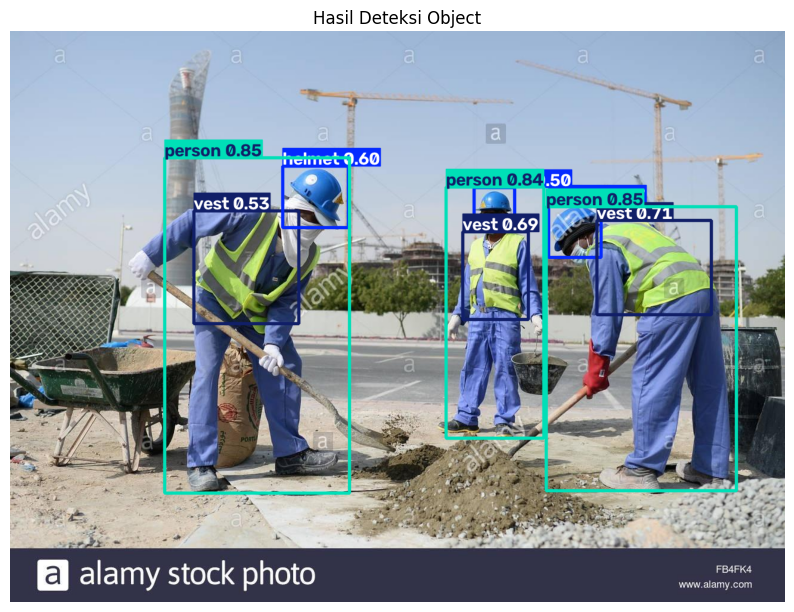

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import glob

# 1. Pastikan file utils.py bisa di-import
from utils import analyze_safety

# 2. Memuat model terbaik yang sudah disimpan di Google Drive
model_path = '/content/drive/MyDrive/For Public Use/Dataset Capstone 4 Ishak/model_best_125_epoch.pt'
print(f"Memuat model dari: {model_path}")
model = YOLO(model_path)

# 3. Mengambil satu gambar acak dari folder test
# Gunakan lokasi gambar test sesuai temuan radar sebelumnya
test_images = glob.glob('/content/dataset/test/images/*.jpg')

if len(test_images) > 0:
    gambar_tes = test_images[0] # Mengambil gambar pertama
    print(f"Melakukan pengujian pada gambar: {gambar_tes}")

    # 4. Melakukan prediksi (Inference)
    hasil_prediksi = model.predict(source=gambar_tes, conf=0.25) # conf=0.25 adalah batas confidence score
    hasil = hasil_prediksi[0]

    # 5. Mengekstrak nama kelas (label) yang terdeteksi
    daftar_deteksi = []
    for box in hasil.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        daftar_deteksi.append(class_name)

    print(f"\nObjek yang terdeteksi: {daftar_deteksi}")

    # 6. Memasukkan hasil deteksi ke logika analitik utils.py
    hasil_hitung, hasil_pesan = analyze_safety(daftar_deteksi)

    print("\n--- HASIL ANALISIS KESELAMATAN ---")
    print(f"Rincian Hitungan: {hasil_hitung}")
    print(f"Kesimpulan: {hasil_pesan}")
    print("----------------------------------\n")

    # 7. Menampilkan gambar hasil deteksi (berisi kotak bounding box)
    gambar_plot = hasil.plot() # Fungsi bawaan YOLO untuk menggambar kotak deteksi
    gambar_plot_rgb = cv2.cvtColor(gambar_plot, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(gambar_plot_rgb)
    plt.axis('off')
    plt.title("Hasil Deteksi Object")
    plt.show()

else:
    print("Gambar test tidak ditemukan, pastikan folder /content/dataset/test/images/ memiliki gambar.")

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr
import cv2
import os
from ultralytics import YOLO
from utils import analyze_safety

# Memuat model YOLOv8 terbaik
model_path = '/content/drive/MyDrive/For Public Use/Dataset Capstone 4 Ishak/model_best_125_epoch.pt'
model = YOLO(model_path)

def predict_and_analyze(input_image):
    if input_image is None:
        return None, "Silakan unggah gambar terlebih dahulu."

    # 1. Jalankan pra-pemeriksaan area konstruksi
    # Gradio mengirimkan numpy array dalam format RGB, is_construction_site butuh BGR jika menggunakan OpenCV
    input_image_bgr = cv2.cvtColor(input_image, cv2.COLOR_RGB2BGR)
    apakah_konstruksi, skor_visual = is_construction_site(input_image_bgr, threshold_score=0.15)

    if not apakah_konstruksi:
        pesan_filter = f"[BLOCKED] Deteksi dilewati. Gambar ini diidentifikasi BUKAN area konstruksi (Skor: {skor_visual:.4f} < Threshold: 0.15). Hal ini untuk mencegah false positive pada objek non-konstruksi."
        return input_image, pesan_filter

    # 2. Jika valid dan lolos sensor, jalankan prediksi YOLOv8
    results = model.predict(source=input_image, conf=0.15)
    result = results[0]

    # Ambil hasil deteksi kelas
    daftar_deteksi = []
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        daftar_deteksi.append(class_name)

    # Analisis keselamatan menggunakan utils.py
    _, pesan_analisis = analyze_safety(daftar_deteksi)

    # Gabungkan informasi skor kelayakan konteks
    pesan_final = f"[PASSED] Terdeteksi sebagai area konstruksi aktif (Skor: {skor_visual:.4f}).\n\n{pesan_analisis}"

    # Plot bounding box pada gambar
    annotated_image = result.plot()
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

    return annotated_image_rgb, pesan_final

# Membuat interface Gradio
interface = gr.Interface(
    fn=predict_and_analyze,
    inputs=gr.Image(type="numpy", label="Unggah Gambar Pekerja/Konstruksi"),
    outputs=[
        gr.Image(type="numpy", label="Hasil Deteksi Alat Keselamatan"),
        gr.Textbox(label="Hasil Analisis & Filter Konteks")
    ],
    title="Sistem Deteksi APD Pekerja Konstruksi (dengan Filter Konteks)",
    description="Unggah gambar area kerja konstruksi untuk mendeteksi penggunaan APD. Sistem dilengkapi fitur pre-filter otomatis untuk menghindari kesalahan deteksi pada gambar non-konstruksi."
)

# Menjalankan interface Gradio
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://24555bad2656f360f3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
